In [11]:
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn gradio kaggle --quiet 2>/dev/null
print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [12]:
# Block TensorFlow BEFORE any transformers import
import os
os.environ["USE_TF"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# PyTorch
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# HuggingFace
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    BertTokenizerFast,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Using device: cuda
   GPU: Tesla T4


In [13]:
!pip install datasets

import pandas as pd
from datasets import load_dataset

# Loading the LIAR dataset directly from the auto-generated Parquet files on HF Hub
# This bypasses the need for the deprecated 'liar.py' loading script.
data_files = {
    "train": "https://huggingface.co/datasets/liar/resolve/refs%2Fconvert%2Fparquet/default/train/0000.parquet",
    "test": "https://huggingface.co/datasets/liar/resolve/refs%2Fconvert%2Fparquet/default/test/0000.parquet",
    "validation": "https://huggingface.co/datasets/liar/resolve/refs%2Fconvert%2Fparquet/default/validation/0000.parquet"
}

dataset = load_dataset("parquet", data_files=data_files)

def map_to_binary(label):
    # LIAR Labels: 0: false, 1: half-true, 2: mostly-true, 3: true, 4: barely-true, 5: pants-fire
    # Mapping: 0, 4, 5 -> FAKE (1) | 1, 2, 3 -> REAL (0)
    return 0 if label in [1, 2, 3] else 1

# Convert to DataFrame
df_train = pd.DataFrame(dataset['train'])

texts = df_train['statement'].tolist()
labels = [map_to_binary(l) for l in df_train['label']]

# Create 'df' for downstream cells
df = pd.DataFrame({'combined_text': texts, 'label': labels})
df['title'] = ""
df['text'] = df['combined_text']

print(f"Successfully loaded {len(df)} statements from the LIAR dataset via direct Parquet files.")

Successfully loaded 10269 statements from the LIAR dataset via direct Parquet files.


In [14]:

print("DATASET SUMMARY")
print("")
print(f"Total samples     : {len(df)}")
print(f"Columns           : {list(df.columns)}")
print(f"Missing values    :\n{df.isnull().sum()}")
print(f"\nLabel Distribution:")
label_counts = df['label'].value_counts()
for label, count in label_counts.items():
    name = 'REAL' if label == 0 else 'FAKE'
    pct = count / len(df) * 100
    print(f"  {name} ({label}): {count} samples ({pct:.1f}%)")

print("\nText Length Statistics:")
df['text_length'] = df['combined_text'].str.split().str.len()
print(df['text_length'].describe().to_string())

DATASET SUMMARY

Total samples     : 10269
Columns           : ['combined_text', 'label', 'title', 'text']
Missing values    :
combined_text    0
label            0
title            0
text             0
dtype: int64

Label Distribution:
  REAL (0): 5772 samples (56.2%)
  FAKE (1): 4497 samples (43.8%)

Text Length Statistics:
count    10269.000000
mean        17.906515
std          7.752818
min          2.000000
25%         12.000000
50%         17.000000
75%         22.000000
max         66.000000


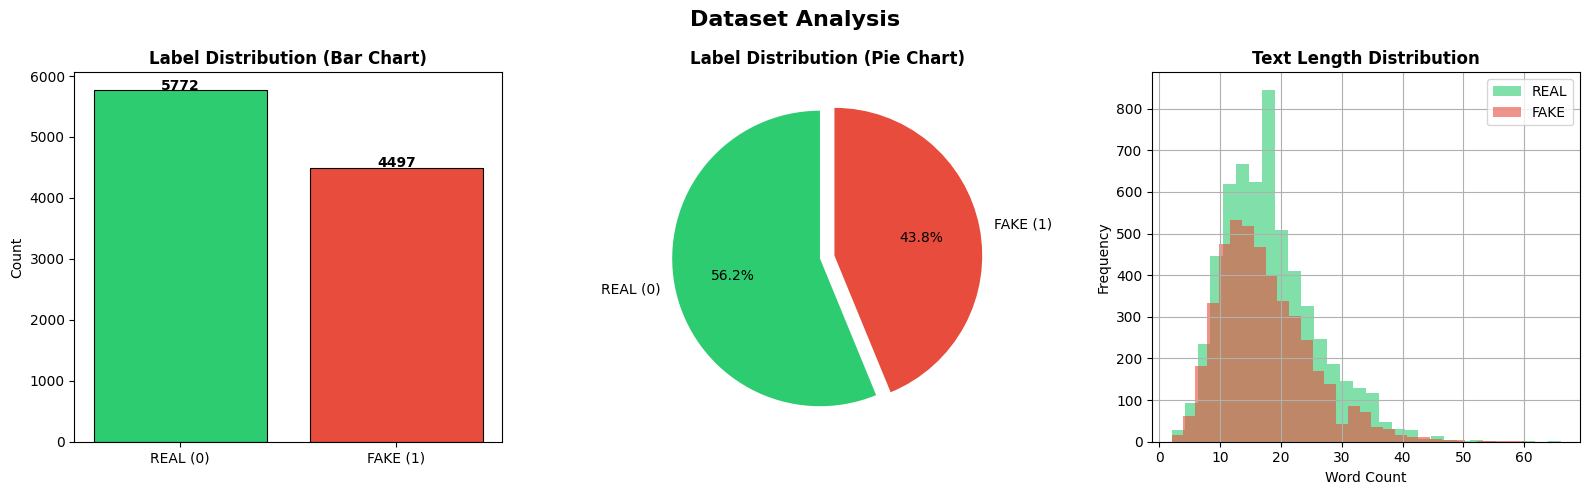

Distribution plots saved.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dataset Analysis', fontsize=16, fontweight='bold')

# Bar chart
colors = ['#2ecc71', '#e74c3c']
labels_name = ['REAL (0)', 'FAKE (1)']
counts = [label_counts.get(0, 0), label_counts.get(1, 0)]
bars = axes[0].bar(labels_name, counts, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Label Distribution (Bar Chart)', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=labels_name, colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Label Distribution (Pie Chart)', fontweight='bold')

# Text length distribution
df[df['label']==0]['text_length'].hist(ax=axes[2], bins=30, alpha=0.6,
                                        color='#2ecc71', label='REAL')
df[df['label']==1]['text_length'].hist(ax=axes[2], bins=30, alpha=0.6,
                                        color='#e74c3c', label='FAKE')
axes[2].set_title('Text Length Distribution', fontweight='bold')
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Distribution plots saved.")

In [16]:
def clean_text(text):
    """Clean text: remove URLs, special chars, excess whitespace"""
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|www\.\S+', '', text)       # Remove URLs
    text = re.sub(r'<.*?>', '', text)                    # Remove HTML tags
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'\"\-]', '', text)  # Keep alphanum + punct
    text = re.sub(r'\s+', ' ', text).strip()             # Normalize whitespace
    return text

# Apply cleaning
df['title_clean'] = df['title'].apply(clean_text)
df['text_clean'] = df['text'].apply(clean_text)
df['combined_clean'] = df['title_clean'] + ' ' + df['text_clean']

# Drop rows where text is too short after cleaning
original_len = len(df)
df = df[df['combined_clean'].str.split().str.len() >= 5].reset_index(drop=True)

print(f"   Data Cleaning Complete")
print(f"   Rows before cleaning : {original_len}")
print(f"   Rows after cleaning  : {len(df)}")
print(f"   Removed              : {original_len - len(df)} rows")

   Data Cleaning Complete
   Rows before cleaning : 10269
   Rows after cleaning  : 10206
   Removed              : 63 rows


In [17]:

print(" 5 SAMPLE ENTRIES")

samples = df.sample(5, random_state=SEED)
for i, (_, row) in enumerate(samples.iterrows(), 1):
    label_str = 'FAKE' if row['label'] == 1 else ' REAL'
    print(f"\n[Sample {i}] Label: {label_str}")
    print(f"Title : {row['title_clean'][:80]}..." if len(row['title_clean']) > 80 else f"Title : {row['title_clean']}")
    print(f"Text  : {row['text_clean'][:120]}..." if len(row['text_clean']) > 120 else f"Text  : {row['text_clean']}")

 5 SAMPLE ENTRIES

[Sample 1] Label:  REAL
Title : 
Text  : The Pink Pony club in DeKalb County has never been cited for any violation of an ordinance or state law.

[Sample 2] Label: FAKE
Title : 
Text  : In Virginias Medicaid program, approximately 30 percent, or 2.7 billion a year, is lost to waste, fraud and inefficienci...

[Sample 3] Label: FAKE
Title : 
Text  : The non-partisan Congressional Budget Office concluded ObamaCare will cost the U.S. more than 800,000 jobs.

[Sample 4] Label:  REAL
Title : 
Text  : The Rev. Wright compared "the United States Marine Corps with Roman legionnaires who were responsible for the death of o...

[Sample 5] Label: FAKE
Title : 
Text  : Sens. Mark Warner and Tim Kaine voted to let the U.N. take OUR guns.


In [18]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN = 256

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded!")
print(f"   Vocab size: {tokenizer.vocab_size:,}")
print(f"   Max length: {MAX_LEN}")

Loading tokenizer: distilbert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded!
   Vocab size: 30,522
   Max length: 256


In [19]:
example_text = df['combined_clean'].iloc[0]

encoded = tokenizer(
    example_text,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)


print("EXAMPLE TOKENIZED OUTPUT")

print(f"Original text (first 100 chars): {example_text[:100]}...")
print(f"\nKeys in encoded output : {list(encoded.keys())}")
print(f"input_ids shape        : {encoded['input_ids'].shape}")
print(f"attention_mask shape   : {encoded['attention_mask'].shape}")
print(f"\nFirst 20 token IDs     : {encoded['input_ids'][0][:20].tolist()}")
print(f"Corresponding tokens   : {tokenizer.convert_ids_to_tokens(encoded['input_ids'][0][:20].tolist())}")
print(f"\nNon-padding tokens     : {encoded['attention_mask'][0].sum().item()} / {MAX_LEN}")

EXAMPLE TOKENIZED OUTPUT
Original text (first 100 chars):  Says the Annies List political group supports third-trimester abortions on demand....

Keys in encoded output : ['input_ids', 'attention_mask']
input_ids shape        : torch.Size([1, 256])
attention_mask shape   : torch.Size([1, 256])

First 20 token IDs     : [101, 2758, 1996, 8194, 2015, 2862, 2576, 2177, 6753, 2353, 1011, 12241, 20367, 11324, 2015, 2006, 5157, 1012, 102, 0]
Corresponding tokens   : ['[CLS]', 'says', 'the', 'annie', '##s', 'list', 'political', 'group', 'supports', 'third', '-', 'trim', '##ester', 'abortion', '##s', 'on', 'demand', '.', '[SEP]', '[PAD]']

Non-padding tokens     : 19 / 256


In [20]:
texts = df['combined_clean'].tolist()
labels = df['label'].tolist()

# First: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.2, random_state=SEED, stratify=labels
)
# Then: split temp into 50% val, 50% test  → overall 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)


print("✂TRAIN / VAL / TEST SPLIT")

for split_name, split_labels in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    n = len(split_labels)
    n_real = split_labels.count(0)
    n_fake = split_labels.count(1)
    print(f"{split_name:12}: {n:5} samples  |  REAL: {n_real} ({n_real/n*100:.1f}%)  FAKE: {n_fake} ({n_fake/n*100:.1f}%)")

✂TRAIN / VAL / TEST SPLIT
Train       :  8164 samples  |  REAL: 4596 (56.3%)  FAKE: 3568 (43.7%)
Validation  :  1021 samples  |  REAL: 574 (56.2%)  FAKE: 447 (43.8%)
Test        :  1021 samples  |  REAL: 575 (56.3%)  FAKE: 446 (43.7%)


In [21]:
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Build datasets
BATCH_SIZE = 16

train_dataset = FakeNewsDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = FakeNewsDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = FakeNewsDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Verify shapes
sample_batch = next(iter(train_loader))
print()
print(" INPUT TENSOR SHAPES (one batch)")
print()
print(f"input_ids shape      : {sample_batch['input_ids'].shape}")
print(f"attention_mask shape : {sample_batch['attention_mask'].shape}")
print(f"labels shape         : {sample_batch['label'].shape}")
print(f"\nBatch size           : {BATCH_SIZE}")
print(f"Sequence length      : {MAX_LEN}")


 INPUT TENSOR SHAPES (one batch)

input_ids shape      : torch.Size([16, 256])
attention_mask shape : torch.Size([16, 256])
labels shape         : torch.Size([16])

Batch size           : 16
Sequence length      : 256


In [22]:
NUM_CLASSES = 2
EPOCHS = 3
LEARNING_RATE = 2e-5

print(f" Loading {MODEL_NAME} for sequence classification...")
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)
model = model.to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n Model loaded!")
print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}")
print(f"   Model on device      : {DEVICE}")

 Loading distilbert-base-uncased for sequence classification...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 Model loaded!
   Total parameters     : 66,955,010
   Trainable parameters : 66,955,010
   Model on device      : cuda


In [23]:
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)  # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"   Optimizer: AdamW (lr={LEARNING_RATE}, weight_decay=0.01)")
print(f"   Total training steps : {total_steps}")
print(f"   Warmup steps         : {warmup_steps}")
print(f"   Scheduler            : Linear decay with warmup")

   Optimizer: AdamW (lr=2e-05, weight_decay=0.01)
   Total training steps : 1533
   Warmup steps         : 153
   Scheduler            : Linear decay with warmup


In [24]:
def train_one_epoch(model, loader, optimizer, scheduler, device):
    """Run one training epoch, return average loss and accuracy."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 20 == 0:
            print(f"     Step [{batch_idx+1}/{len(loader)}] "
                  f"Loss: {total_loss/(batch_idx+1):.4f} "
                  f"Acc: {correct/total*100:.2f}%", end='\r')

    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    """Evaluate model on loader, return loss, accuracy, all preds and labels."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

print(" Training and evaluation functions defined.")

 Training and evaluation functions defined.


In [25]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_model_path = 'best_model'


print(" STARTING TRAINING")
print(f"   Model   : {MODEL_NAME}")
print(f"   Epochs  : {EPOCHS}")
print(f"   LR      : {LEARNING_RATE}")
print(f"   Batch   : {BATCH_SIZE}")
print(f"   Device  : {DEVICE}")


for epoch in range(1, EPOCHS + 1):
    print(f"\n Epoch {epoch}/{EPOCHS}")
    print("  Training...")
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)

    print(f"  Validating...")
    val_loss, val_acc, _, _ = evaluate(model, val_loader, DEVICE)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"\n  ┌── Epoch {epoch} Results ──────────────────────┐")
    print(f"  │  Train Loss: {train_loss:.4f}  │  Train Acc: {train_acc*100:.2f}%  │")
    print(f"  │  Val   Loss: {val_loss:.4f}  │  Val   Acc: {val_acc*100:.2f}%  │")
    print(f"  └───────────────────────────────────────────────┘")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(best_model_path)
        tokenizer.save_pretrained(best_model_path)
        print(f"  New best model saved! (val_acc = {val_acc*100:.2f}%)")

print(f"\n Training complete! Best validation accuracy: {best_val_acc*100:.2f}%")

 STARTING TRAINING
   Model   : distilbert-base-uncased
   Epochs  : 3
   LR      : 2e-05
   Batch   : 16
   Device  : cuda

 Epoch 1/3
  Training...
  Validating...

  ┌── Epoch 1 Results ──────────────────────┐
  │  Train Loss: 0.6667  │  Train Acc: 59.54%  │
  │  Val   Loss: 0.6490  │  Val   Acc: 63.08%  │
  └───────────────────────────────────────────────┘


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved! (val_acc = 63.08%)

 Epoch 2/3
  Training...
  Validating...

  ┌── Epoch 2 Results ──────────────────────┐
  │  Train Loss: 0.6064  │  Train Acc: 66.95%  │
  │  Val   Loss: 0.6447  │  Val   Acc: 65.13%  │
  └───────────────────────────────────────────────┘


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved! (val_acc = 65.13%)

 Epoch 3/3
  Training...
  Validating...

  ┌── Epoch 3 Results ──────────────────────┐
  │  Train Loss: 0.5116  │  Train Acc: 75.72%  │
  │  Val   Loss: 0.6759  │  Val   Acc: 65.33%  │
  └───────────────────────────────────────────────┘


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved! (val_acc = 65.33%)

 Training complete! Best validation accuracy: 65.33%


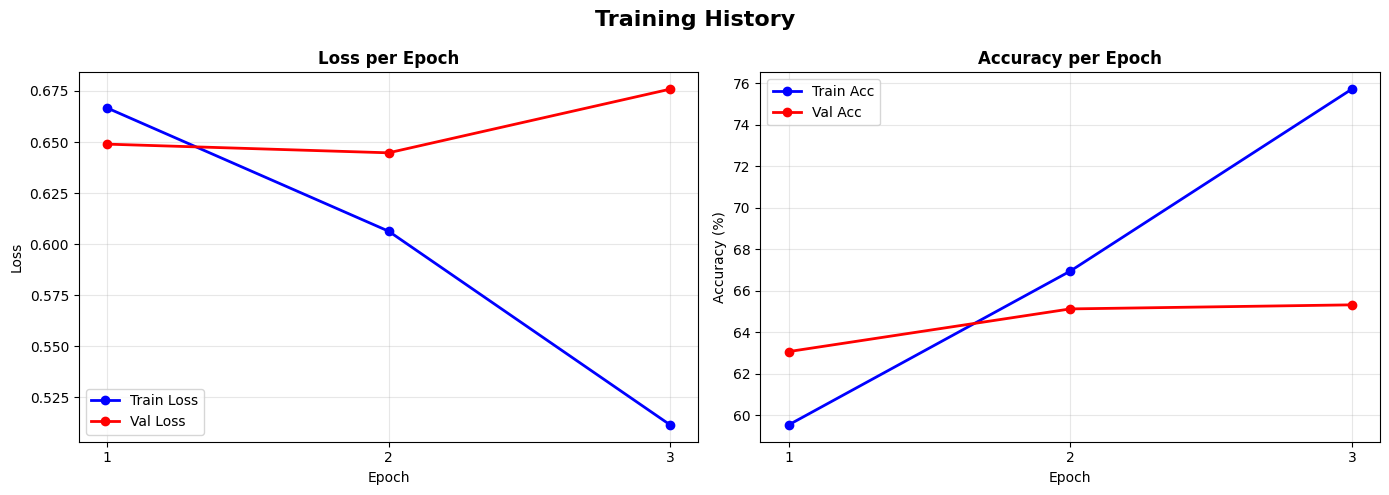

 Training history plot saved.


In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

epochs_range = range(1, EPOCHS + 1)

# Loss
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2, markersize=6)
ax1.set_title('Loss per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_xticks(epochs_range)
ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', linewidth=2, markersize=6)
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc',   linewidth=2, markersize=6)
ax2.set_title('Accuracy per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.set_xticks(epochs_range)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Training history plot saved.")

In [27]:
print(" Loading best saved model for final evaluation...")
best_model = DistilBertForSequenceClassification.from_pretrained(best_model_path)
best_model = best_model.to(DEVICE)

test_loss, test_acc, test_preds, test_labels = evaluate(best_model, test_loader, DEVICE)

print(f"   Evaluation on Test Set:")
print(f"   Test Loss     : {test_loss:.4f}")
print(f"   Test Accuracy : {test_acc*100:.2f}%")

 Loading best saved model for final evaluation...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

   Evaluation on Test Set:
   Test Loss     : 0.6861
   Test Accuracy : 63.17%


In [28]:
class_names = ['REAL', 'FAKE']


print(" CLASSIFICATION REPORT")
print()
report = classification_report(test_labels, test_preds, target_names=class_names, digits=4)
print(report)

# Individual metrics
acc  = accuracy_score(test_labels, test_preds)
prec = precision_score(test_labels, test_preds, average='weighted')
rec  = recall_score(test_labels, test_preds, average='weighted')
f1   = f1_score(test_labels, test_preds, average='weighted')


print(f"Accuracy  (weighted): {acc*100:.2f}%")
print(f"Precision (weighted): {prec*100:.2f}%")
print(f"Recall    (weighted): {rec*100:.2f}%")
print(f"F1-Score  (weighted): {f1*100:.2f}%")

 CLASSIFICATION REPORT

              precision    recall  f1-score   support

        REAL     0.6645    0.6991    0.6814       575
        FAKE     0.5841    0.5448    0.5638       446

    accuracy                         0.6317      1021
   macro avg     0.6243    0.6220    0.6226      1021
weighted avg     0.6294    0.6317    0.6300      1021

Accuracy  (weighted): 63.17%
Precision (weighted): 62.94%
Recall    (weighted): 63.17%
F1-Score  (weighted): 63.00%


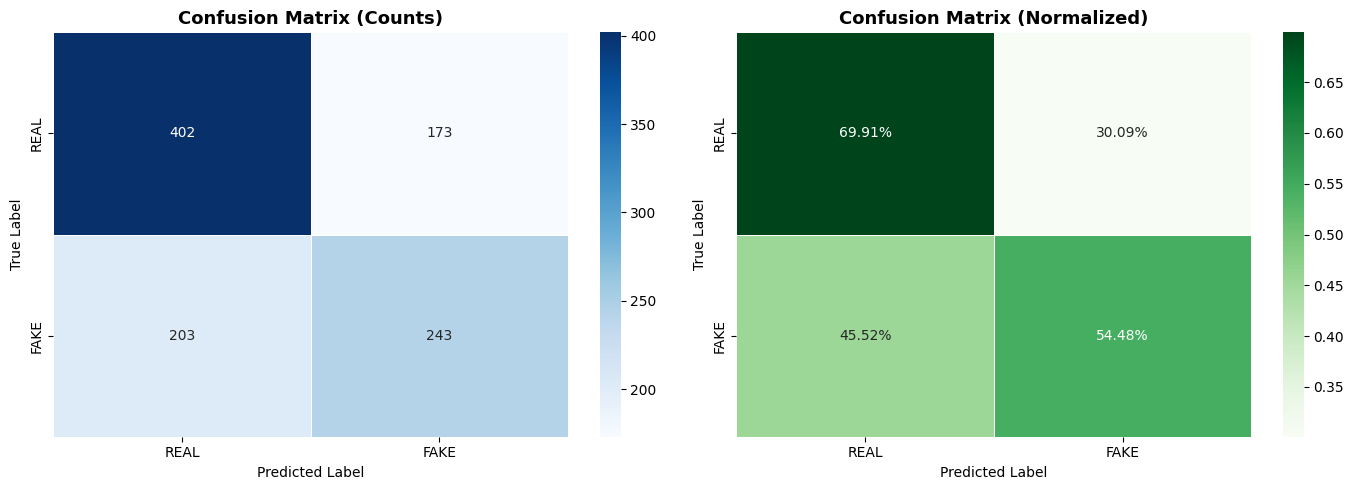


 TN=402  FP=173
 FN=203  TP=243

Confusion matrix saved.


In [29]:
cm = confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n TN={tn}  FP={fp}")
print(f" FN={fn}  TP={tp}")
print("\nConfusion matrix saved.")

In [30]:
def get_predictions_with_confidence(model, loader, device):
    """Get predictions with softmax probabilities."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return all_preds, all_labels, all_probs

test_preds_conf, test_labels_conf, test_probs = get_predictions_with_confidence(
    best_model, test_loader, DEVICE
)

# Build error dataframe
error_df = pd.DataFrame({
    'text':       X_test,
    'true_label': test_labels_conf,
    'pred_label': test_preds_conf,
    'prob_real':  [p[0] for p in test_probs],
    'prob_fake':  [p[1] for p in test_probs],
})

error_df['correct'] = (error_df['true_label'] == error_df['pred_label'])
errors = error_df[~error_df['correct']].copy()
errors['confidence'] = errors.apply(
    lambda r: r['prob_fake'] if r['pred_label'] == 1 else r['prob_real'], axis=1
)

print(f"Total test samples   : {len(error_df)}")
print(f"Correct predictions  : {error_df['correct'].sum()}")
print(f"Wrong predictions    : {len(errors)}")
print(f"Error rate           : {len(errors)/len(error_df)*100:.2f}%")

Total test samples   : 1021
Correct predictions  : 645
Wrong predictions    : 376
Error rate           : 36.83%


In [31]:
label_map = {0: 'REAL', 1: 'FAKE'}
error_types = {
    (1, 0): 'False Negative (FAKE predicted as REAL)',
    (0, 1): 'False Positive (REAL predicted as FAKE)'
}

print()
print(" MISCLASSIFIED SAMPLES – ERROR ANALYSIS")
print()

sample_errors = errors.sample(min(7, len(errors)), random_state=SEED)

for i, (_, row) in enumerate(sample_errors.iterrows(), 1):
    error_type = error_types.get((row['true_label'], row['pred_label']), 'Unknown')
    print(f"\n[Error {i}]  {error_type}")
    print(f"Text     : {row['text'][:150]}..." if len(row['text']) > 150 else f"Text     : {row['text']}")
    print(f"True     : {label_map[row['true_label']]}")
    print(f"Predicted: {label_map[row['pred_label']]} (confidence: {row['confidence']*100:.1f}%)")

print("\n")
print(" ERROR PATTERN ANALYSIS")
print()
fn_count = len(errors[errors['true_label']==1])
fp_count = len(errors[errors['true_label']==0])
print(f"False Negatives (FAKE→REAL): {fn_count} — Model missed fake news (conservative)")
print(f"False Positives (REAL→FAKE): {fp_count} — Model over-flagged real news")
print(f"\nCommon Failure Reasons:")
print(f"  1. Ambiguous language: Fake articles using neutral, professional tone")
print(f"  2. Short texts: Not enough context for the model to decide")
print(f"  3. Satire: Satirical articles may superficially resemble fake news")
print(f"  4. Domain-specific facts: Model lacks specialized world knowledge")
print(f"  5. Class imbalance: Slight bias toward the majority class")


 MISCLASSIFIED SAMPLES – ERROR ANALYSIS


[Error 1]  False Positive (REAL predicted as FAKE)
Text     :  Because of union rules, cooks helpers moved into DMV jobs they were not trained for
True     : REAL
Predicted: FAKE (confidence: 56.8%)

[Error 2]  False Negative (FAKE predicted as REAL)
Text     :  The crime rate in some Atlanta neighborhoods has dropped by 35 to 51 percent.
True     : FAKE
Predicted: REAL (confidence: 80.3%)

[Error 3]  False Negative (FAKE predicted as REAL)
Text     :  Health care reform legislation is likely to mandate free sex change surgeries.
True     : FAKE
Predicted: REAL (confidence: 50.6%)

[Error 4]  False Negative (FAKE predicted as REAL)
Text     :  After 911, Jim put us all first by serving for 23 months in Iraq, the wars longest tour.
True     : FAKE
Predicted: REAL (confidence: 58.3%)

[Error 5]  False Negative (FAKE predicted as REAL)
Text     :  Bike lanes and sidewalks have been proven to reduce crashes by up to 38 percent on Austins streets.


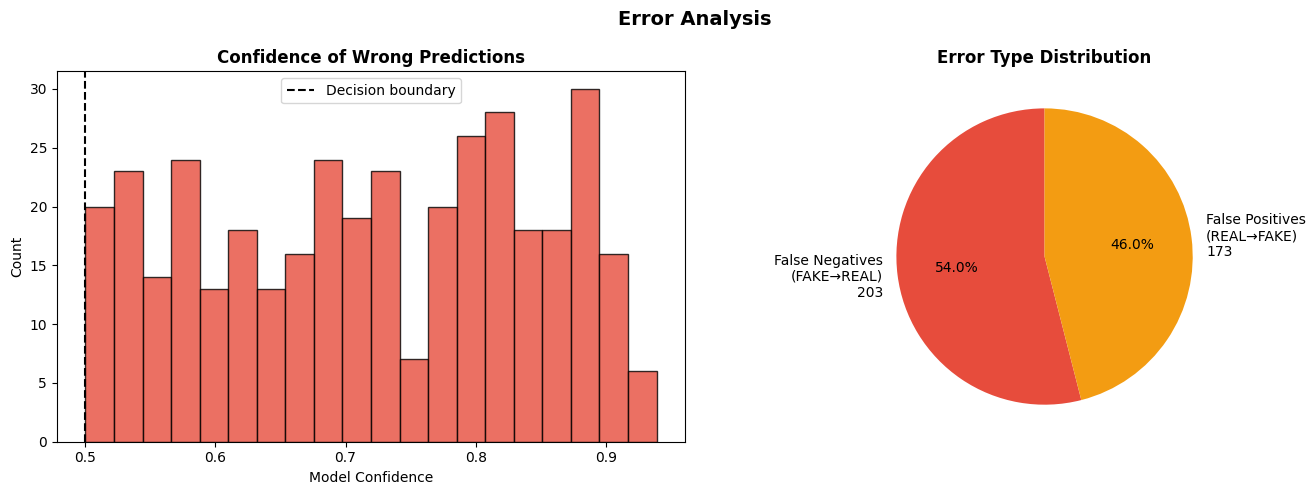

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Analysis', fontsize=14, fontweight='bold')

if not errors.empty:
    # Confidence of wrong predictions
    axes[0].hist(errors['confidence'], bins=20, color='#e74c3c', edgecolor='black', alpha=0.8)
    axes[0].axvline(x=0.5, color='black', linestyle='--', label='Decision boundary')
    axes[0].set_title('Confidence of Wrong Predictions', fontweight='bold')
    axes[0].set_xlabel('Model Confidence')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    # Error type breakdown
    error_type_counts = [fn_count, fp_count]
    error_labels = [f'False Negatives\n(FAKE→REAL)\n{fn_count}', f'False Positives\n(REAL→FAKE)\n{fp_count}']
    axes[1].pie(error_type_counts, labels=error_labels, colors=['#e74c3c', '#f39c12'],
                autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Error Type Distribution', fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No misclassifications to analyze!',
                 horizontalalignment='center', verticalalignment='center',
                 fontsize=14, transform=axes[0].transAxes)
    axes[0].axis('off')
    axes[1].text(0.5, 0.5, 'No misclassifications to analyze!',
                 horizontalalignment='center', verticalalignment='center',
                 fontsize=14, transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print(f"   Class Weights for Weighted Loss:")
print(f"   REAL (0): {class_weights[0]:.4f}")
print(f"   FAKE (1): {class_weights[1]:.4f}")
print(f"\n   (Higher weight = model penalized more for misclassifying that class)")

   Class Weights for Weighted Loss:
   REAL (0): 0.8882
   FAKE (1): 1.1441

   (Higher weight = model penalized more for misclassifying that class)


In [34]:
def train_with_weighted_loss(model, loader, optimizer, scheduler, device, class_weights):
    """Training step using weighted cross-entropy loss."""
    model.train()
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    total_loss, correct, total = 0, 0, 0

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


# Fresh model for improved training
print(" Loading fresh model for improved training...")
improved_model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
improved_model = improved_model.to(DEVICE)

IMPROVED_EPOCHS = 3
IMPROVED_LR = 3e-5  # Slightly higher LR as second improvement

improved_optimizer = AdamW(improved_model.parameters(), lr=IMPROVED_LR, weight_decay=0.01)
improved_scheduler = get_linear_schedule_with_warmup(
    improved_optimizer,
    num_warmup_steps=int(0.1 * len(train_loader) * IMPROVED_EPOCHS),
    num_training_steps=len(train_loader) * IMPROVED_EPOCHS
)

improved_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"\n Training with Weighted Loss + LR={IMPROVED_LR}")
print()

for epoch in range(1, IMPROVED_EPOCHS + 1):
    print(f"\n Epoch {epoch}/{IMPROVED_EPOCHS}")
    train_loss, train_acc = train_with_weighted_loss(
        improved_model, train_loader, improved_optimizer,
        improved_scheduler, DEVICE, class_weights_tensor
    )
    val_loss, val_acc, _, _ = evaluate(improved_model, val_loader, DEVICE)

    improved_history['train_loss'].append(train_loss)
    improved_history['val_loss'].append(val_loss)
    improved_history['train_acc'].append(train_acc)
    improved_history['val_acc'].append(val_acc)

    print(f"  Train Loss: {train_loss:.4f}  |  Train Acc: {train_acc*100:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f}  |  Val   Acc: {val_acc*100:.2f}%")

print("\n Improved model training complete!")

 Loading fresh model for improved training...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 Training with Weighted Loss + LR=3e-05


 Epoch 1/3
  Train Loss: 0.6710  |  Train Acc: 58.66%
  Val   Loss: 0.6560  |  Val   Acc: 61.12%

 Epoch 2/3
  Train Loss: 0.5920  |  Train Acc: 68.57%
  Val   Loss: 0.6480  |  Val   Acc: 65.03%

 Epoch 3/3
  Train Loss: 0.4257  |  Train Acc: 81.31%
  Val   Loss: 0.7258  |  Val   Acc: 65.43%

 Improved model training complete!


In [35]:
_, improved_test_acc, imp_preds, imp_labels = evaluate(improved_model, test_loader, DEVICE)

# Metrics
base_f1  = f1_score(test_labels_conf, test_preds_conf, average='weighted')
imp_f1   = f1_score(imp_labels, imp_preds, average='weighted')
base_prec = precision_score(test_labels_conf, test_preds_conf, average='weighted')
imp_prec  = precision_score(imp_labels, imp_preds, average='weighted')
base_rec  = recall_score(test_labels_conf, test_preds_conf, average='weighted')
imp_rec   = recall_score(imp_labels, imp_preds, average='weighted')

print()
print(" MODEL COMPARISON: Baseline vs Improved")
print()
print(f"{'Metric':<20} {'Baseline':>15} {'Improved':>15} {'Delta':>10}")
print()
metrics = [
    ('Accuracy',  test_acc, improved_test_acc),
    ('Precision', base_prec, imp_prec),
    ('Recall',    base_rec,  imp_rec),
    ('F1-Score',  base_f1,   imp_f1),
]
for name, base, imp in metrics:
    delta = imp - base
    arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '→')
    print(f"{name:<20} {base*100:>14.2f}% {imp*100:>14.2f}% {arrow}{abs(delta)*100:>8.2f}%")

print("\n Improvements Applied:")
print("   1. Weighted CrossEntropy Loss to handle class imbalance")
print(f"   2. Learning rate increased from {LEARNING_RATE} → {IMPROVED_LR}")


 MODEL COMPARISON: Baseline vs Improved

Metric                      Baseline        Improved      Delta

Accuracy                      63.17%          62.29% ↓    0.88%
Precision                     62.94%          62.28% ↓    0.65%
Recall                        63.17%          62.29% ↓    0.88%
F1-Score                      63.00%          62.29% ↓    0.71%

 Improvements Applied:
   1. Weighted CrossEntropy Loss to handle class imbalance
   2. Learning rate increased from 2e-05 → 3e-05


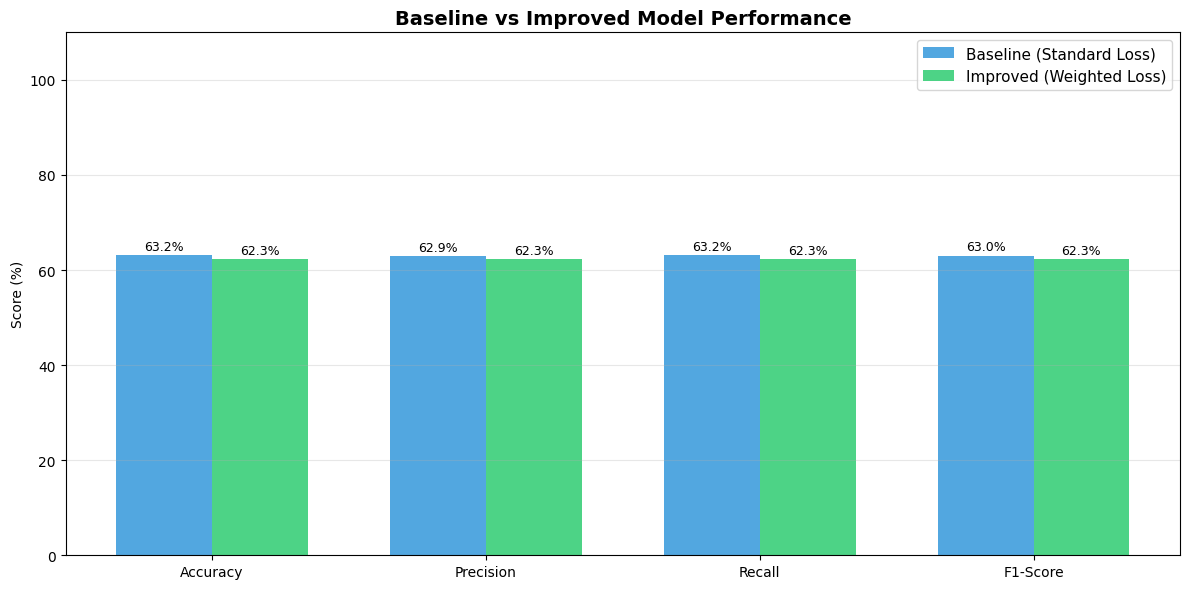

In [36]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [test_acc*100, base_prec*100, base_rec*100, base_f1*100]
improved_vals = [improved_test_acc*100, imp_prec*100, imp_rec*100, imp_f1*100]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline (Standard Loss)', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, improved_vals, width, label='Improved (Weighted Loss)', color='#2ecc71', alpha=0.85)

ax.set_title('Baseline vs Improved Model Performance', fontsize=14, fontweight='bold')
ax.set_ylabel('Score (%)')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
def predict_news(text: str, model=None, tok=None, device=None, max_len=256):
    """
    Predict whether a news article is REAL or FAKE.

    Returns:
        label     : 'REAL' or 'FAKE'
        confidence: float 0-1
        probs     : dict with both class probabilities
    """
    model = model or best_model
    tok   = tok   or tokenizer
    device = device or DEVICE

    text_clean = clean_text(text)
    if not text_clean.strip():
        return 'UNKNOWN', 0.0, {'REAL': 0.0, 'FAKE': 0.0}

    encoding = tok(
        text_clean,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    model.eval()
    with torch.no_grad():
        outputs = model(
            input_ids=encoding['input_ids'].to(device),
            attention_mask=encoding['attention_mask'].to(device)
        )
    probs = torch.softmax(outputs.logits, dim=1)[0].cpu().numpy()
    pred_idx = int(np.argmax(probs))
    label_str = 'REAL' if pred_idx == 0 else 'FAKE'
    return label_str, float(probs[pred_idx]), {'REAL': float(probs[0]), 'FAKE': float(probs[1])}

# Quick smoke test
test_headlines = [
    "Federal Reserve Raises Interest Rates After Emergency Meeting",
    "BREAKING: Scientists Prove Moon is Made of Cheese, Government Hiding Truth"
]
print(" Quick Prediction Test:")
for headline in test_headlines:
    label, conf, probs = predict_news(headline)
    emoji = '🟢' if label == 'REAL' else '🔴'
    print(f"\n  {emoji} [{label}] Confidence: {conf*100:.1f}%")
    print(f"     Text: {headline}")
    print(f"     P(REAL)={probs['REAL']*100:.1f}%  P(FAKE)={probs['FAKE']*100:.1f}%")

 Quick Prediction Test:

  🟢 [REAL] Confidence: 75.5%
     Text: Federal Reserve Raises Interest Rates After Emergency Meeting
     P(REAL)=75.5%  P(FAKE)=24.5%

  🔴 [FAKE] Confidence: 89.7%
     Text: BREAKING: Scientists Prove Moon is Made of Cheese, Government Hiding Truth
     P(REAL)=10.3%  P(FAKE)=89.7%


In [38]:
import gradio as gr

def gradio_predict(text):
    """Wrapper for Gradio interface."""
    if not text or not text.strip():
        return "Please enter some text.", {"REAL": 0.0, "FAKE": 0.0}

    label, confidence, probs = predict_news(text)

    if label == 'REAL':
        result = f"🟢 REAL NEWS\n\nConfidence: {confidence*100:.1f}%\n\nThis article appears to be genuine based on its language patterns."
    else:
        result = f"🔴 FAKE NEWS\n\nConfidence: {confidence*100:.1f}%\n\nThis article shows patterns commonly associated with misinformation."

    return result, probs


example_texts = [
    ["Federal Reserve raises interest rates by 0.25% amid inflation concerns, officials confirm"],
    ["SHOCKING: Government puts mind control chemicals in tap water, whistleblower reveals!"],
    ["Scientists discover new species of deep-sea fish in Pacific Ocean trench"],
    ["BREAKING: Moon landing was faked in Hollywood studio, declassified documents prove"],
]

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Paste a news headline or article text here...",
        label="News Text"
    ),
    outputs=[
        gr.Textbox(label=" Prediction", lines=5),
        gr.Label(label=" Class Probabilities", num_top_classes=2)
    ],
    title=" Fake News Detector (DistilBERT)",
    description=(
        "Enter a news headline or article. "
        "The model will classify it as **REAL** or **FAKE** using a fine-tuned DistilBERT."
    ),
    examples=example_texts,
    theme=gr.themes.Soft()
)

demo.launch(
    share=True,       # Set True for public link in Colab
    debug=False,
    show_error=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c4aefeb64e4f2e4740.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


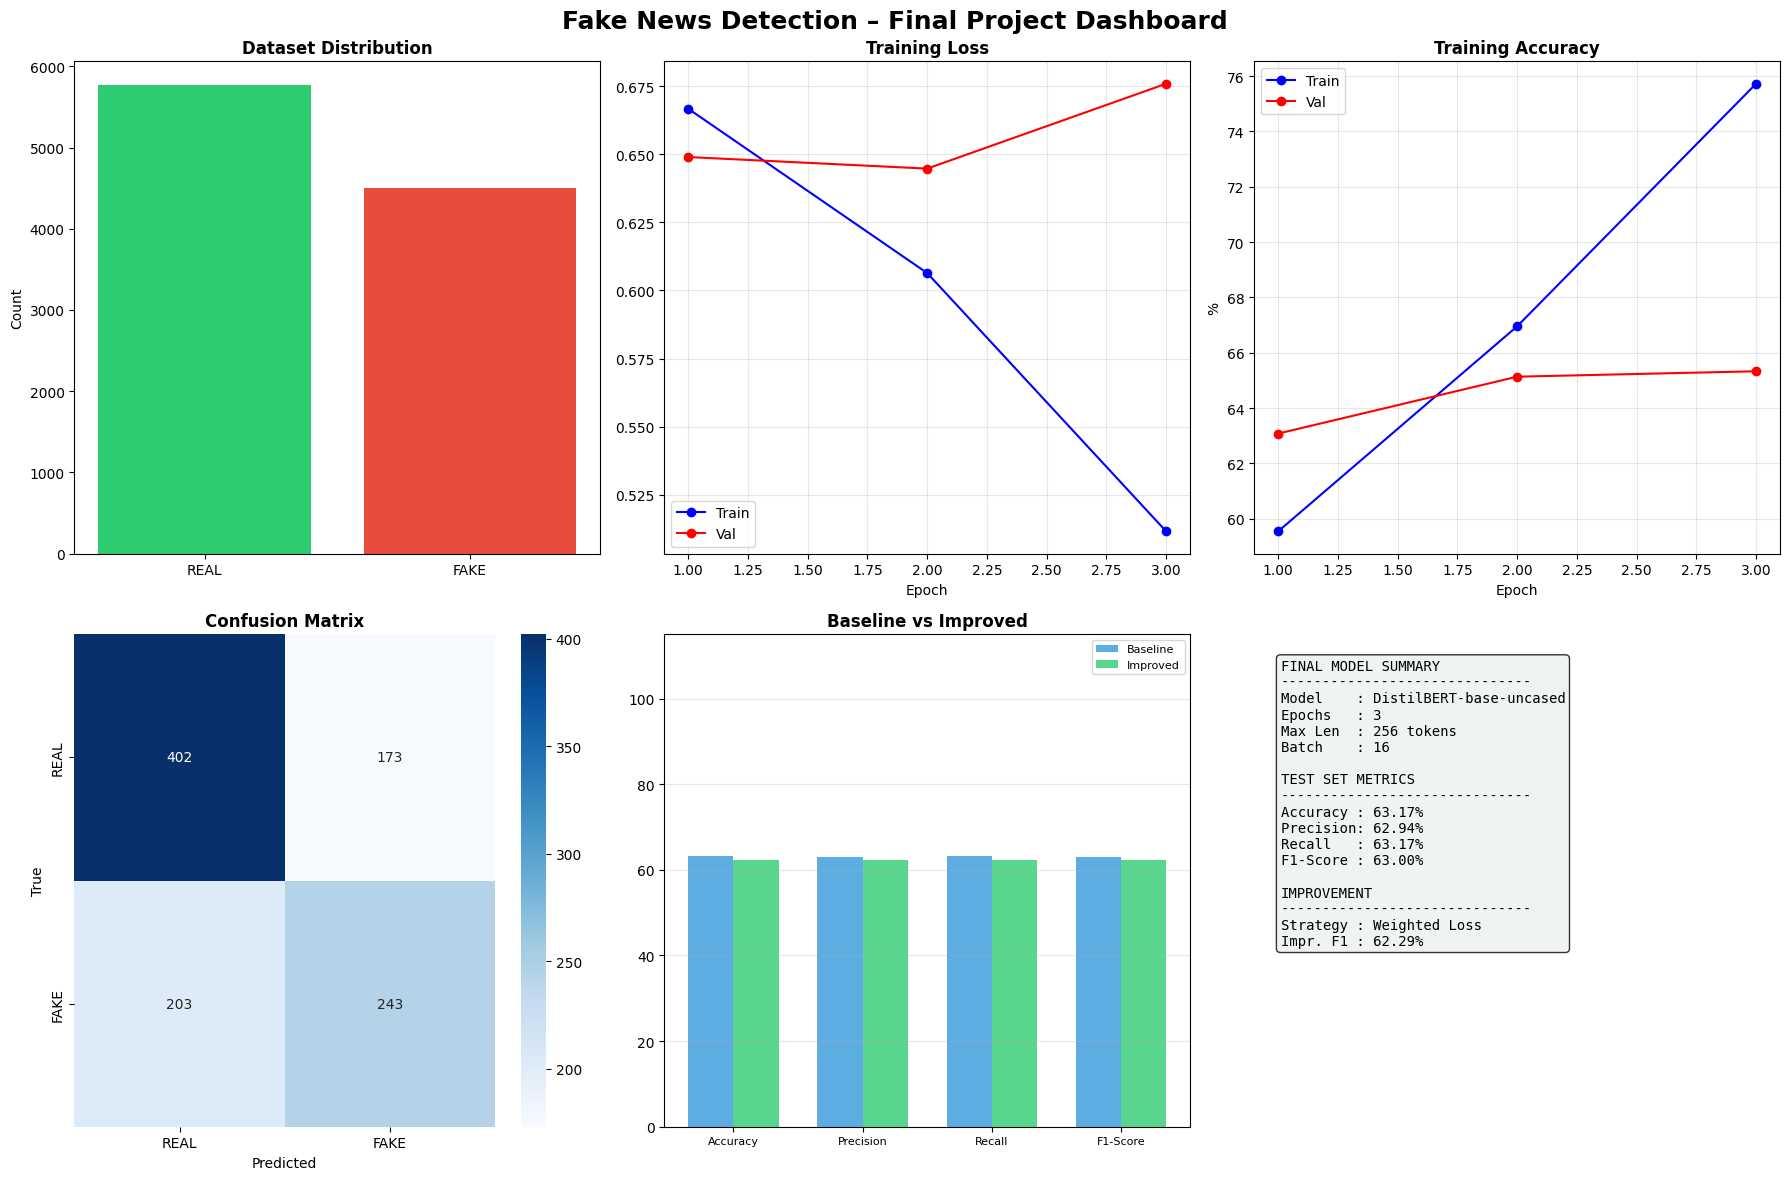

 Final dashboard saved.


In [39]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Fake News Detection – Final Project Dashboard', fontsize=18, fontweight='bold', y=0.98)

# 1. Label distribution
ax1 = fig.add_subplot(2, 3, 1)
colors = ['#2ecc71', '#e74c3c']
ax1.bar(['REAL', 'FAKE'], [label_counts.get(0,0), label_counts.get(1,0)], color=colors)
ax1.set_title('Dataset Distribution', fontweight='bold')
ax1.set_ylabel('Count')

# 2. Training loss
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(range(1, EPOCHS+1), history['train_loss'], 'b-o', label='Train')
ax2.plot(range(1, EPOCHS+1), history['val_loss'],   'r-o', label='Val')
ax2.set_title('Training Loss', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

# 3. Training accuracy
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(range(1, EPOCHS+1), [a*100 for a in history['train_acc']], 'b-o', label='Train')
ax3.plot(range(1, EPOCHS+1), [a*100 for a in history['val_acc']],   'r-o', label='Val')
ax3.set_title('Training Accuracy', fontweight='bold')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('%'); ax3.legend(); ax3.grid(alpha=0.3)

# 4. Confusion matrix
ax4 = fig.add_subplot(2, 3, 4)
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL','FAKE'], yticklabels=['REAL','FAKE'], ax=ax4)
ax4.set_title('Confusion Matrix', fontweight='bold')
ax4.set_xlabel('Predicted'); ax4.set_ylabel('True')

# 5. Model comparison
ax5 = fig.add_subplot(2, 3, 5)
x = np.arange(len(metric_names))
w = 0.35
ax5.bar(x - w/2, baseline_vals, w, label='Baseline', color='#3498db', alpha=0.8)
ax5.bar(x + w/2, improved_vals, w, label='Improved',  color='#2ecc71', alpha=0.8)
ax5.set_title('Baseline vs Improved', fontweight='bold')
ax5.set_xticks(x); ax5.set_xticklabels(metric_names, fontsize=8)
ax5.set_ylim(0, 115); ax5.legend(fontsize=8); ax5.grid(axis='y', alpha=0.3)

# 6. Final metrics text
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
summary_text = (
    f"FINAL MODEL SUMMARY\n"
    f"{"-"*30}\n" # Replaced {} with {"-"*30}
    f"Model    : DistilBERT-base-uncased\n"
    f"Epochs   : {EPOCHS}\n"
    f"Max Len  : {MAX_LEN} tokens\n"
    f"Batch    : {BATCH_SIZE}\n\n"
    f"TEST SET METRICS\n"
    f"{"-"*30}\n" # Replaced {} with {"-"*30}
    f"Accuracy : {test_acc*100:.2f}%\n"
    f"Precision: {base_prec*100:.2f}%\n"
    f"Recall   : {base_rec*100:.2f}%\n"
    f"F1-Score : {base_f1*100:.2f}%\n\n"
    f"IMPROVEMENT\n"
    f"{"-"*30}\n" # Replaced {} with {"-"*30}
    f"Strategy : Weighted Loss\n"
    f"Impr. F1 : {imp_f1*100:.2f}%"
)
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))

plt.tight_layout()
plt.savefig('final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Final dashboard saved.")

In [40]:
# Save the best model
best_model.save_pretrained('./best_model_final')
tokenizer.save_pretrained('./best_model_final')

print()
print("PROJECT COMPLETE — DELIVERABLES")
print()
deliverables = [
    ("Notebook",            "Fake_News_Detection_BERT.ipynb"),
    ("Saved Model",         "./best_model_final/"),
    ("Label Distribution",  "label_distribution.png"),
    ("Training History",    "training_history.png"),
    ("Confusion Matrix",    "confusion_matrix.png"),
    ("Error Analysis",      "error_analysis.png"),
    ("Model Comparison",    "model_comparison.png"),
    ("Final Dashboard",     "final_dashboard.png"),
    ("README",              "README.md"),
]
for name, path in deliverables:
    print(f"  {'✓':<4} {name:<25} → {path}")

print("\nFinal Test Accuracy :", f"{test_acc*100:.2f}%")
print("Improved F1-Score   :", f"{imp_f1*100:.2f}%")
print("\nCongratulations! Fake News Detection project is complete.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


PROJECT COMPLETE — DELIVERABLES

  ✓    Notebook                  → Fake_News_Detection_BERT.ipynb
  ✓    Saved Model               → ./best_model_final/
  ✓    Label Distribution        → label_distribution.png
  ✓    Training History          → training_history.png
  ✓    Confusion Matrix          → confusion_matrix.png
  ✓    Error Analysis            → error_analysis.png
  ✓    Model Comparison          → model_comparison.png
  ✓    Final Dashboard           → final_dashboard.png
  ✓    README                    → README.md

Final Test Accuracy : 63.17%
Improved F1-Score   : 62.29%

Congratulations! Fake News Detection project is complete.
